In [1]:
import pandas as pd

df = pd.read_csv('../vmlab/data/trees/tree_B10_cycle_030405.csv')

print(df.to_string()) 

        id  parent_id  topology__cycle arch_dev__pot_flowering_date  arch_dev__pot_nb_fruit  topology__ancestor_is_apical  arch_dev_rep__nature  topology__ancestor_nature  arch_dev__nb_inflos  topology__is_apical  topology__appearance_month
0        0        NaN                3                          NaT                       0                           NaN                     0                        NaN                    0                    1                         NaN
1        1        0.0                3                          NaT                       0                           NaN                     0                        NaN                    0                    0                         NaN
2        2        1.0                3                          NaT                       0                           NaN                     0                        NaN                    0                    0                         NaN
3        3        2.0               

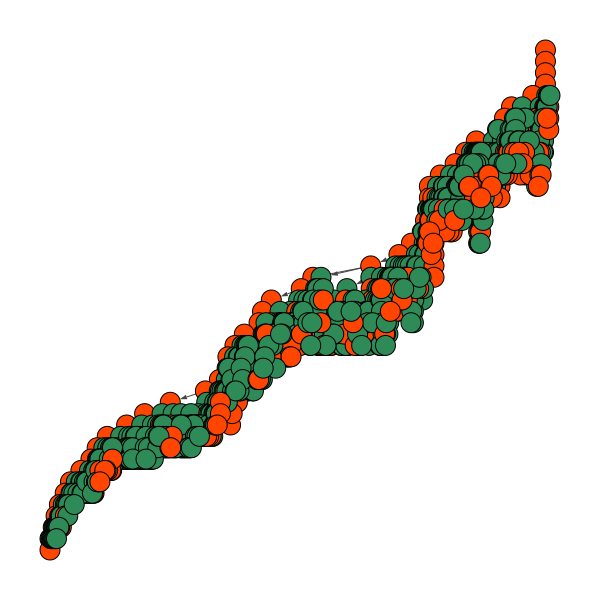

In [52]:
import pandas as pd
import igraph as ig
import matplotlib.pyplot as plt

# 1. Load your data
df = pd.read_csv('../vmlab/data/trees/cone_quercus_data.csv')

# 2. Setup the "Young Oak" modifications
def edit_for_quercus(df):
    # Ensure the main trunk is dominant
    # We want to make sure id 0, 1, 2, 3... stay as the 'apical' leader
    df.loc[df['id'] < 10, 'topology__is_apical'] = 1
    
    # Oaks have clustered buds at the top of a growth cycle
    # We can simulate this by setting nature to vegetative (0) for young trees
    df['arch_dev_rep__nature'] = 0 
    
    # Increase the 'cycle' depth to show multi-year growth
    # Let's say every 10 IDs is a new growth year
    df['topology__cycle'] = df['id'] // 10
    
    return df

df_oak = edit_for_quercus(df.copy())

# 3. Build the Graph
# Filter out 'NA' parent_ids for the edge list
edges = df_oak[df_oak['parent_id'].notna() & (df_oak['parent_id'] != 'NA')]
edge_list = list(zip(edges['parent_id'].astype(int), edges['id'].astype(int)))

graph_size = len(df_oak)
#g = ig.Graph.Directed(edge_list)
g=ig.Graph(directed=True)
g.add_vertices(graph_size)
#g.vs['fname'] = edges['id']

g.add_edges(edge_list)
# 4. Set Visual Attributes based on your CSV columns
g.vs["is_apical"] = df_oak['topology__is_apical'].tolist()
g.vs["cycle"] = df_oak['topology__cycle'].tolist()

# Define colors: Red for apical leader, Green for lateral branches
layout = g.layout_reingold_tilford(root=[0]) # Tree-style layout
visual_style = {
    "vertex_size": 20,
    "vertex_color": ["#FF4500" if a == 1 else "#2E8B57" for a in g.vs["is_apical"]],
    #"vertex_label": g.vs["id"],
    "edge_arrow_size": 0.5,
    "layout": layout,
    "bbox": (600, 600),
    "margin": 50
}

# Plot
ig.plot(g, **visual_style)

In [37]:
print(len(df['id']) - 1) 

4127


In [44]:
import pandas as pd
import numpy as np

def generate_quercus_with_fruit(target_rows=1446, filename="quercus_sim_data.csv"):
    print(f"Generating Oak (Quercus) structure with {target_rows} nodes...")
    
    # Columns required by the simulation
    data = []
    
    # Tracker to ensure a parent only has ONE apical (extending) child
    # Key = parent_id, Value = True if it already has an apical child
    parent_has_apical = {}
    
    # 1. ROOT NODE (Rows 0)
    # [id, parent_id, cycle, flow_date, nb_fruit, anc_apical, nature, anc_nature, inflos, is_apical, month]
    # Root is always ID 0, Parent -1 (converted to NA later)
    data.append([0, -1, 1, pd.NaT, 0, pd.NA, 0, pd.NA, 0, 1, pd.NA])
    
    # Lists to manage growth
    # "buds" are the IDs of nodes that can still grow children
    trunk_buds = [0]
    crown_buds = []
    
    current_id = 1

    # --- PHASE 1: THE TRUNK (Robust vertical growth) ---
    # We force the first 30 nodes to constitute the main structure
    while current_id < 30:
        parent = current_id - 1 # Strict linear growth for the trunk
        
        # Trunk nodes are always apical (extending upward)
        is_apical = 1
        parent_has_apical[parent] = True
        
        # Trunk is thick wood (nature 0), no fruit
        data.append([current_id, parent, 1, pd.NaT, 0, 1, 0, 0, 0, is_apical, 1])
        
        # Add to crown candidates once the trunk is tall enough
        if current_id > 10:
            crown_buds.append(current_id)
            
        current_id += 1

    # --- PHASE 2: THE CROWN (Wide spreading branches + Acorns) ---
    while current_id < target_rows:
        
        # Pick a random parent from the available buds
        # We prefer older parts of the crown to create thick main branches
        parent = np.random.choice(crown_buds)
        
        # Determine if this new node is an extension (apical) or a side branch (lateral)
        if parent_has_apical.get(parent, False):
            is_apical = 0 # Parent already has a leader, this must be a side branch
        else:
            # 60% chance to extend the branch, 40% chance to stop and force lateral
            is_apical = 1 if np.random.rand() > 0.4 else 0
            if is_apical: parent_has_apical[parent] = True

        # --- BIOLOGY: FRUIT LOGIC (ACORNS) ---
        # Oaks bear fruit on tips or short spurs.
        # If the node is lateral (0) and high up in the ID count (younger), chance for fruit.
        nature = 0 # Default wood
        nb_fruit = 0
        
        # 15% chance of being a fruiting node, BUT only if it's not the main trunk
        if is_apical == 0 and np.random.rand() < 0.15:
            nature = 2 # 2 = Fruiting Unit
            nb_fruit = np.random.randint(1, 4) # 1 to 3 acorns
        
        # Cycle Logic: Trunk is 1, branches increase cycle
        parent_cycle = data[parent][2]
        new_cycle = parent_cycle if is_apical else min(5, parent_cycle + 1)

        # Add the node
        data.append([
            current_id, 
            parent, 
            new_cycle, 
            pd.NaT, 
            nb_fruit,   # Fruit count
            1,          # Ancestor is apical (simplified)
            nature,     # 0=Wood, 2=Fruit
            0,          # Ancestor nature
            0,          # Inflos (flowers)
            is_apical, 
            np.random.randint(1, 12) # Month
        ])
        
        # Add this new node to the pool of buds so it can grow too
        crown_buds.append(current_id)
        
        # Remove the parent from buds occasionally to simulate stopping growth
        if len(crown_buds) > 200:
            crown_buds.pop(0) # Remove old wood from growing pool
            
        current_id += 1

    # --- DATAFRAME CLEANUP ---
    columns = [
        "id", "parent_id", "topology__cycle", "arch_dev__pot_flowering_date",
        "arch_dev__pot_nb_fruit", "topology__ancestor_is_apical", 
        "arch_dev_rep__nature", "topology__ancestor_nature", 
        "arch_dev__nb_inflos", "topology__is_apical", "topology__appearance_month"
    ]
    df = pd.DataFrame(data, columns=columns)

    # Convert IDs to Nullable Integers
    df['id'] = df['id'].astype("Int64")
    df['parent_id'] = df['parent_id'].astype("Int64")

    # FIX: Set Root Parent to NA
    df.loc[df['id'] == 0, 'parent_id'] = pd.NA

    # Save
    df.to_csv(filename, index=False, na_rep="NA")
    print(f"--- SUCCESS ---")
    print(f"File saved to: {filename}")
    print(f"Generated {len(df[df['arch_dev_rep__nature']==2])} fruiting nodes (Acorns).")

# Run it
generate_quercus_with_fruit()

Generating Oak (Quercus) structure with 1446 nodes...
--- SUCCESS ---
File saved to: quercus_sim_data.csv
Generated 132 fruiting nodes (Acorns).


## Quercus mannager?(cone shape)

In [2]:
import pandas as pd
import numpy as np

def generate_crash_proof_quercus(target_rows=1446, filename="cone_quercus_data.csv"):
    print(f"Generating Crash-Proof Paleo-Oak...")

    # --- CONFIGURATION ---
    TRUNK_HEIGHT = 45
    BASE_WIDTH = 12
    
    # --- REGISTRY SYSTEMS ---
    # 1. Geometry: Where are the nodes? {id: {'z': height, 'x': width}}
    node_geom = {0: {'z': 0, 'x': 0}}
    
    # 2. Topology: Who already has a leader? {parent_id: True}
    # This prevents the "nb_apical_children <= 1" error
    has_apical_child = {}

    # Data Storage
    # [id, parent, cycle, date, fruit, anc_apical, nature, anc_nature, inflos, is_apical, month]
    data = []
    
    # Initialize Root
    # Root has no parent (-1), cycle 1, wood (0)
    data.append([0, -1, 1, pd.NaT, 0, pd.NA, 0, pd.NA, 0, 1, pd.NA])
    
    current_id = 1
    active_tips = [] # Candidates for growth

    # ==========================================
    # PHASE 1: THE TRUNK (Strict Vertical)
    # ==========================================
    print("  > Building Spine...")
    
    prev_id = 0
    trunk_ids = [0]
    
    for h in range(1, TRUNK_HEIGHT):
        parent = prev_id
        
        # The trunk is ALWAYS an extension (Apical)
        is_apical = 1
        
        # Register that this parent now has an apical child
        has_apical_child[parent] = True
        
        # Geometry: Up 1, Out 0
        node_geom[current_id] = {'z': h, 'x': 0}
        
        # Visuals: Tip is Green, rest is Wood
        is_top = (h == TRUNK_HEIGHT - 1)
        nature = 2 if is_top else 0
        
        data.append([current_id, parent, 1, pd.NaT, 0, 1, nature, 0, 0, is_apical, 1])
        
        trunk_ids.append(current_id)
        prev_id = current_id
        current_id += 1

    # ==========================================
    # PHASE 2: THE CONE BRANCHES
    # ==========================================
    print("  > Filling Branches...")
    
    # Add trunk nodes to growth pool (excluding very top/bottom)
    for t_id in trunk_ids:
        if 2 < node_geom[t_id]['z'] < TRUNK_HEIGHT - 2:
            active_tips.append(t_id)

    while current_id < target_rows and len(active_tips) > 0:
        
        # Pick a random parent from our growth pool
        idx = np.random.randint(0, len(active_tips))
        parent = active_tips[idx]
        
        # --- SHAPE LOGIC (Cone) ---
        p_z = node_geom[parent]['z']
        p_x = node_geom[parent]['x']
        
        # Max width decreases as we go up
        rel_height = p_z / TRUNK_HEIGHT
        # CAMBIAR A: Crecimiento Decurrente (Roble Madur / Quercus Olmos)
        max_x = BASE_WIDTH * np.sqrt(max(0, 1.0 - (rel_height)**2))
        
        # If we reached the edge of the cone, stop growing this branch
        if p_x >= max_x:
            active_tips.pop(idx)
            continue

        # --- TOPOLOGY LOGIC (The Fix) ---
        # Rule: A parent can only have ONE apical child.
        
        # Check if parent ALREADY has a leader
        parent_already_has_apical = has_apical_child.get(parent, False)
        
        if parent_already_has_apical:
            # If parent has a leader, we MUST be a side branch (Lateral)
            is_apical = 0
            new_cycle = 2 # Branches increase cycle
        else:
            # If parent is free, we decide randomly
            # If x=0 (Trunk), we force lateral to start the branch
            if p_x == 0:
                is_apical = 0
                new_cycle = 2
            else:
                # 60% chance to extend branch, 40% to fork
                is_apical = 1 if np.random.rand() > 0.4 else 0
                new_cycle = 2
        
        # Register our decision
        if is_apical:
            has_apical_child[parent] = True

        # --- GEOMETRY UPDATE ---
        new_x = p_x + 1
        new_z = p_z # Branches grow horizontally roughly
        node_geom[current_id] = {'z': new_z, 'x': new_x}
        
        # --- VISUALS (Green Tips) ---
        # If we are near the edge, we are a Leaf/Fruit
        dist_edge = max_x - new_x
        if dist_edge < 1.5:
            nature = 2
            nb_fruit = np.random.randint(1, 4)
        else:
            nature = 0
            nb_fruit = 0
            
        # Add Node
        data.append([
            current_id, parent, new_cycle, pd.NaT, nb_fruit, 
            1, nature, 0, 0, is_apical, np.random.randint(1, 12)
        ])
        
        # Add to pool so it can grow too
        active_tips.append(current_id)
        current_id += 1

    # ==========================================
    # SAVE AND CLEANUP
    # ==========================================
    columns = [
        "id", "parent_id", "topology__cycle", "arch_dev__pot_flowering_date",
        "arch_dev__pot_nb_fruit", "topology__ancestor_is_apical", 
        "arch_dev_rep__nature", "topology__ancestor_nature", 
        "arch_dev__nb_inflos", "topology__is_apical", "topology__appearance_month"
    ]
    df = pd.DataFrame(data, columns=columns)
    
    # Strict Types
    df['id'] = df['id'].astype("Int64")
    df['parent_id'] = df['parent_id'].astype("Int64")
    df.loc[df['id'] == 0, 'parent_id'] = pd.NA

    df.to_csv(filename, index=False, na_rep="NA")
    print(f"--- SUCCESS ---")
    print(f"Data saved to {filename}")
    print(f"Total Nodes: {len(df)}")
    print(f"Verified: No parent has >1 apical child.")

# Run
generate_crash_proof_quercus()

Generating Crash-Proof Paleo-Oak...
  > Building Spine...
  > Filling Branches...
--- SUCCESS ---
Data saved to cone_quercus_data.csv
Total Nodes: 1446
Verified: No parent has >1 apical child.


## Generando el Quercus con una distribucion de "Domo"(Decurrent)

In [7]:
import pandas as pd
import numpy as np

def generate_paleo_quercus(target_rows=1500, filename="dome_quercus_data.csv"):
    print("Generating Spreading Paleo-Oak (Decurrent Form)...")

    # --- OAK CONFIGURATION ---
    TRUNK_HEIGHT = 45
    BASE_WIDTH = 25       # Oaks are much wider than cones
    CROWN_START = 15      # The height where the main canopy begins spreading

    # --- REGISTRY SYSTEMS ---
    node_geom = {0: {'z': 0, 'x': 0}}
    has_apical_child = {}

    # Data Storage
    data = []
    
    # Initialize Root
    data.append([0, -1, 1, pd.NaT, 0, pd.NA, 0, pd.NA, 0, 1, pd.NA])
    
    current_id = 1
    active_tips = []

    # ==========================================
    # PHASE 1: THE TRUNK 
    # ==========================================
    print("  > Building Main Trunk...")
    prev_id = 0
    trunk_ids = [0]
    
    for h in range(1, TRUNK_HEIGHT):
        parent = prev_id
        is_apical = 1
        has_apical_child[parent] = True
        
        node_geom[current_id] = {'z': h, 'x': 0}
        
        # Tip is green (2), rest is wood (0)
        is_top = (h == TRUNK_HEIGHT - 1)
        nature = 2 if is_top else 0
        
        data.append([current_id, parent, 1, pd.NaT, 0, 1, nature, 0, 0, is_apical, 1])
        trunk_ids.append(current_id)
        prev_id = current_id
        current_id += 1

    # ==========================================
    # PHASE 2: THE DOME/SPHERE BRANCHES
    # ==========================================
    print("  > Filling Decurrent Canopy...")
    
    # Only allow branches to sprout from the CROWN_START upwards
    for t_id in trunk_ids:
        if CROWN_START <= node_geom[t_id]['z'] < TRUNK_HEIGHT - 2:
            active_tips.append(t_id)

    while current_id < target_rows and len(active_tips) > 0:
        
        idx = np.random.randint(0, len(active_tips))
        parent = active_tips[idx]
        
        p_z = node_geom[parent]['z']
        p_x = node_geom[parent]['x']
        parent_cycle = data[parent][2] # Obtenemos el año/ciclo del padre
        
        # --- SHAPE LOGIC: THE OAK DOME ---
        rel_crown_height = (p_z - CROWN_START) / (TRUNK_HEIGHT - CROWN_START)
        max_x = BASE_WIDTH * np.sqrt(max(0, 1.0 - (rel_crown_height)**2))
        
        if p_x >= max_x:
            active_tips.pop(idx)
            continue

        # --- TOPOLOGY & PROBABILITY LOGIC ---
        parent_already_has_apical = has_apical_child.get(parent, False)
        
        # Distancia relativa al borde (0.0 = en el tronco, 1.0 = en el borde exterior)
        # Esto nos permite cambiar la biología según la posición en la copa
        rel_distance_to_edge = p_x / max_x if max_x > 0 else 1.0
        
        if parent_already_has_apical:
            is_apical = 0
            # Si nace una nueva rama lateral, avanzamos el "año" de crecimiento
            new_cycle = parent_cycle + 1 
        else:
            if p_x == 0:
                is_apical = 0
                new_cycle = parent_cycle + 1
            else:
                # ACROTONÍA Y RAMIFICACIÓN DE BORDE:
                # Cerca del tronco (>0.8) crece recto. Cerca del borde (<0.4) se bifurca mucho.
                prob_extend = 0.85 - (0.4 * rel_distance_to_edge)
                is_apical = 1 if np.random.rand() < prob_extend else 0
                
                # Si se extiende, mantiene el ciclo. Si se bifurca, suma un ciclo.
                new_cycle = parent_cycle if is_apical == 1 else parent_cycle + 1
        
        if is_apical:
            has_apical_child[parent] = True

        # --- GEOMETRY UPDATE (Con Plagiotropismo Realista) ---
        new_x = p_x + 1
        
        # Las ramas de Quercus crecen ligeramente hacia arriba (ortotropía parcial)
        # Cerca del borde, el peso del follaje las aplana.
        if rel_distance_to_edge < 0.7 and np.random.rand() > 0.5:
            new_z = p_z + 1  # Sube ligeramente
        else:
            new_z = p_z      # Crece plano
            
        node_geom[current_id] = {'z': new_z, 'x': new_x}
        
        # --- VISUALS & PHENOLOGY ---
        dist_edge = max_x - new_x
        if dist_edge < 1.5:
            nature = 2 # Unidad Fructífera
            nb_fruit = np.random.randint(1, 4) 
        else:
            nature = 0 # Madera estructural
            nb_fruit = 0
            
        data.append([
            current_id, parent, new_cycle, pd.NaT, nb_fruit, 
            1, nature, 0, 0, is_apical, np.random.randint(4, 9)
        ])
        
        active_tips.append(current_id)
        current_id += 1

    # ==========================================
    # SAVE AND CLEANUP
    # ==========================================
    columns = [
        "id", "parent_id", "topology__cycle", "arch_dev__pot_flowering_date",
        "arch_dev__pot_nb_fruit", "topology__ancestor_is_apical", 
        "arch_dev_rep__nature", "topology__ancestor_nature", 
        "arch_dev__nb_inflos", "topology__is_apical", "topology__appearance_month"
    ]
    df = pd.DataFrame(data, columns=columns)
    
    df['id'] = df['id'].astype("Int64")
    df['parent_id'] = df['parent_id'].astype("Int64")
    df.loc[df['id'] == 0, 'parent_id'] = pd.NA

    df.to_csv(filename, index=False, na_rep="NA")
    print("--- SUCCESS ---")
    print(f"Data saved to {filename}. Total Nodes: {len(df)}")

generate_paleo_quercus()

Generating Spreading Paleo-Oak (Decurrent Form)...
  > Building Main Trunk...
  > Filling Decurrent Canopy...
--- SUCCESS ---
Data saved to dome_quercus_data.csv. Total Nodes: 1500
